Libraries Imported
Folders inside dataset: ['Test_Set_Folder', 'Train_Set_Folder', 'Validation_Set_Folder']


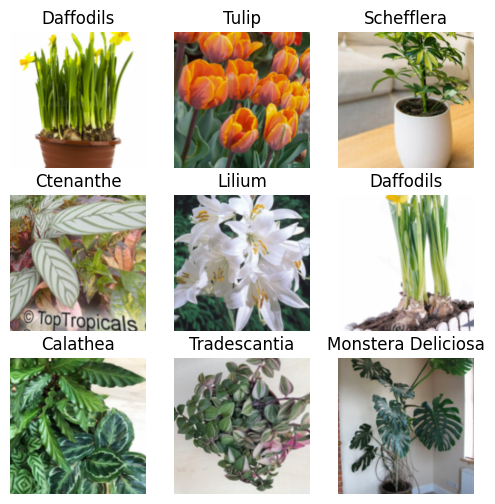

In [ ]:
import os
from fastai.vision.all import *
from PIL import Image
from pathlib import Path
from PIL import Image

print("Libraries Imported")

# Convert all PNG images in the dataset to RGB
def convert_dataset_to_rgb(directory):
    for img_path in Path(directory).rglob("*.png"):  # Find all PNG images
        with Image.open(img_path) as img:
            if img.mode in ("RGBA", "P"):  # If image has transparency
                img = img.convert("RGB")  # Convert to RGB
                img.save(img_path)  # Overwrite the original image

# dataset_path = "/content/drive/My Drive/511 Project/house_plant_species"
dataset_path = Path('C:/Users/rkurr/Documents/University/ENDG511/Project/house_plant_species')

# Print dataset structure
print("Folders inside dataset:", os.listdir(dataset_path))

convert_dataset_to_rgb(dataset_path)

plants = DataBlock(
    blocks=(ImageBlock(), CategoryBlock), 
    get_items=get_image_files,  # Get image file paths
    get_y=parent_label,  # Extract labels from folder structure
    item_tfms=Resize(224),  # Resize images for consistency
    batch_tfms=aug_transforms(size=224, min_scale=0.5, mult=1)  # Data augmentation
)

# Create DataLoaders
dls = plants.dataloaders(dataset_path, bs=25, num_workers=0)

# Show sample images from the dataset
dls.show_batch(max_n=9, figsize=(6,6))

In [2]:
# Create FastAI learner using ResNet18
learn = vision_learner(dls, resnet18, metrics=accuracy)

c:\Users\rkurr\anaconda3\envs\endg411\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rkurr\anaconda3\envs\endg411\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
# Train the model using the best LR found
learn.fine_tune(epochs=15, base_lr=0.019)


epoch,train_loss,valid_loss,accuracy,time
0,1.966898,1.314574,0.672616,15:01


epoch,train_loss,valid_loss,accuracy,time
0,0.910901,0.612508,0.827166,17:30
1,0.890487,1.142229,0.717458,16:32
2,0.942885,1.151578,0.698738,16:34
3,0.935055,1.237695,0.671746,18:30
4,0.775982,0.975972,0.751415,16:51
5,0.723798,0.988951,0.757510,18:33
6,0.590116,0.812587,0.790161,18:28
7,0.491994,0.623841,0.840226,17:57
8,0.378480,0.563419,0.851110,17:52
9,0.331018,0.515857,0.871136,17:50


In [4]:
# Save the trained model
learn.export('fine_tuned_plant_classifier_model_v1_base.pkl')

print("Training complete. Model saved successfully.")

Training complete. Model saved successfully.


In [13]:
print(len(learn.dls.valid_ds))

2297


In [ ]:
# Save the DataLoaders
import pickle
with open('v1_dls.pkl', 'wb') as f:
    pickle.dump(learn.dls, f)

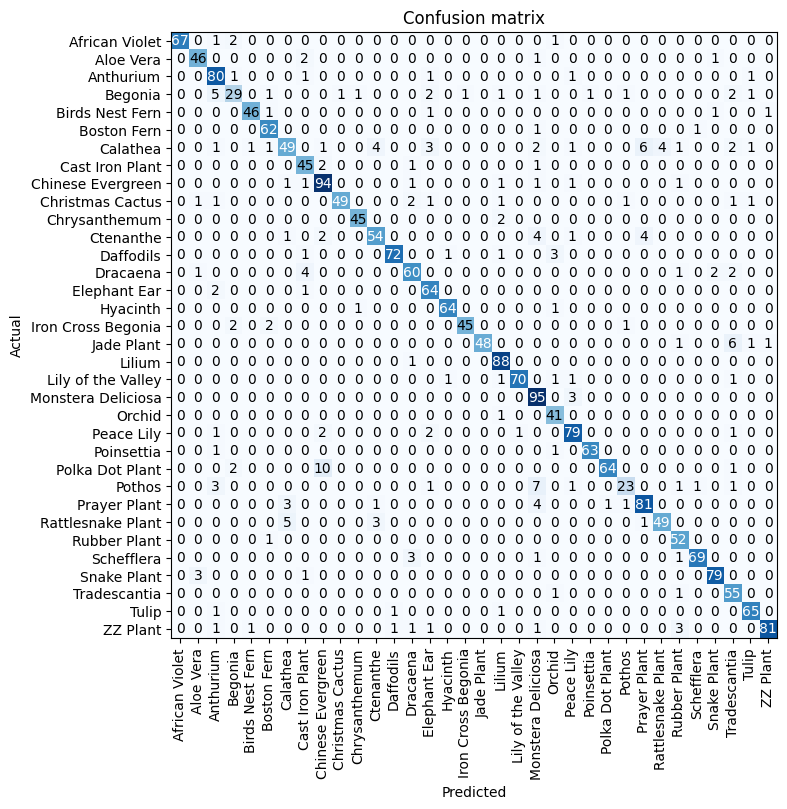

In [5]:
# Confusion Matrix
from fastai.interpret import ClassificationInterpretation

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(8,8))

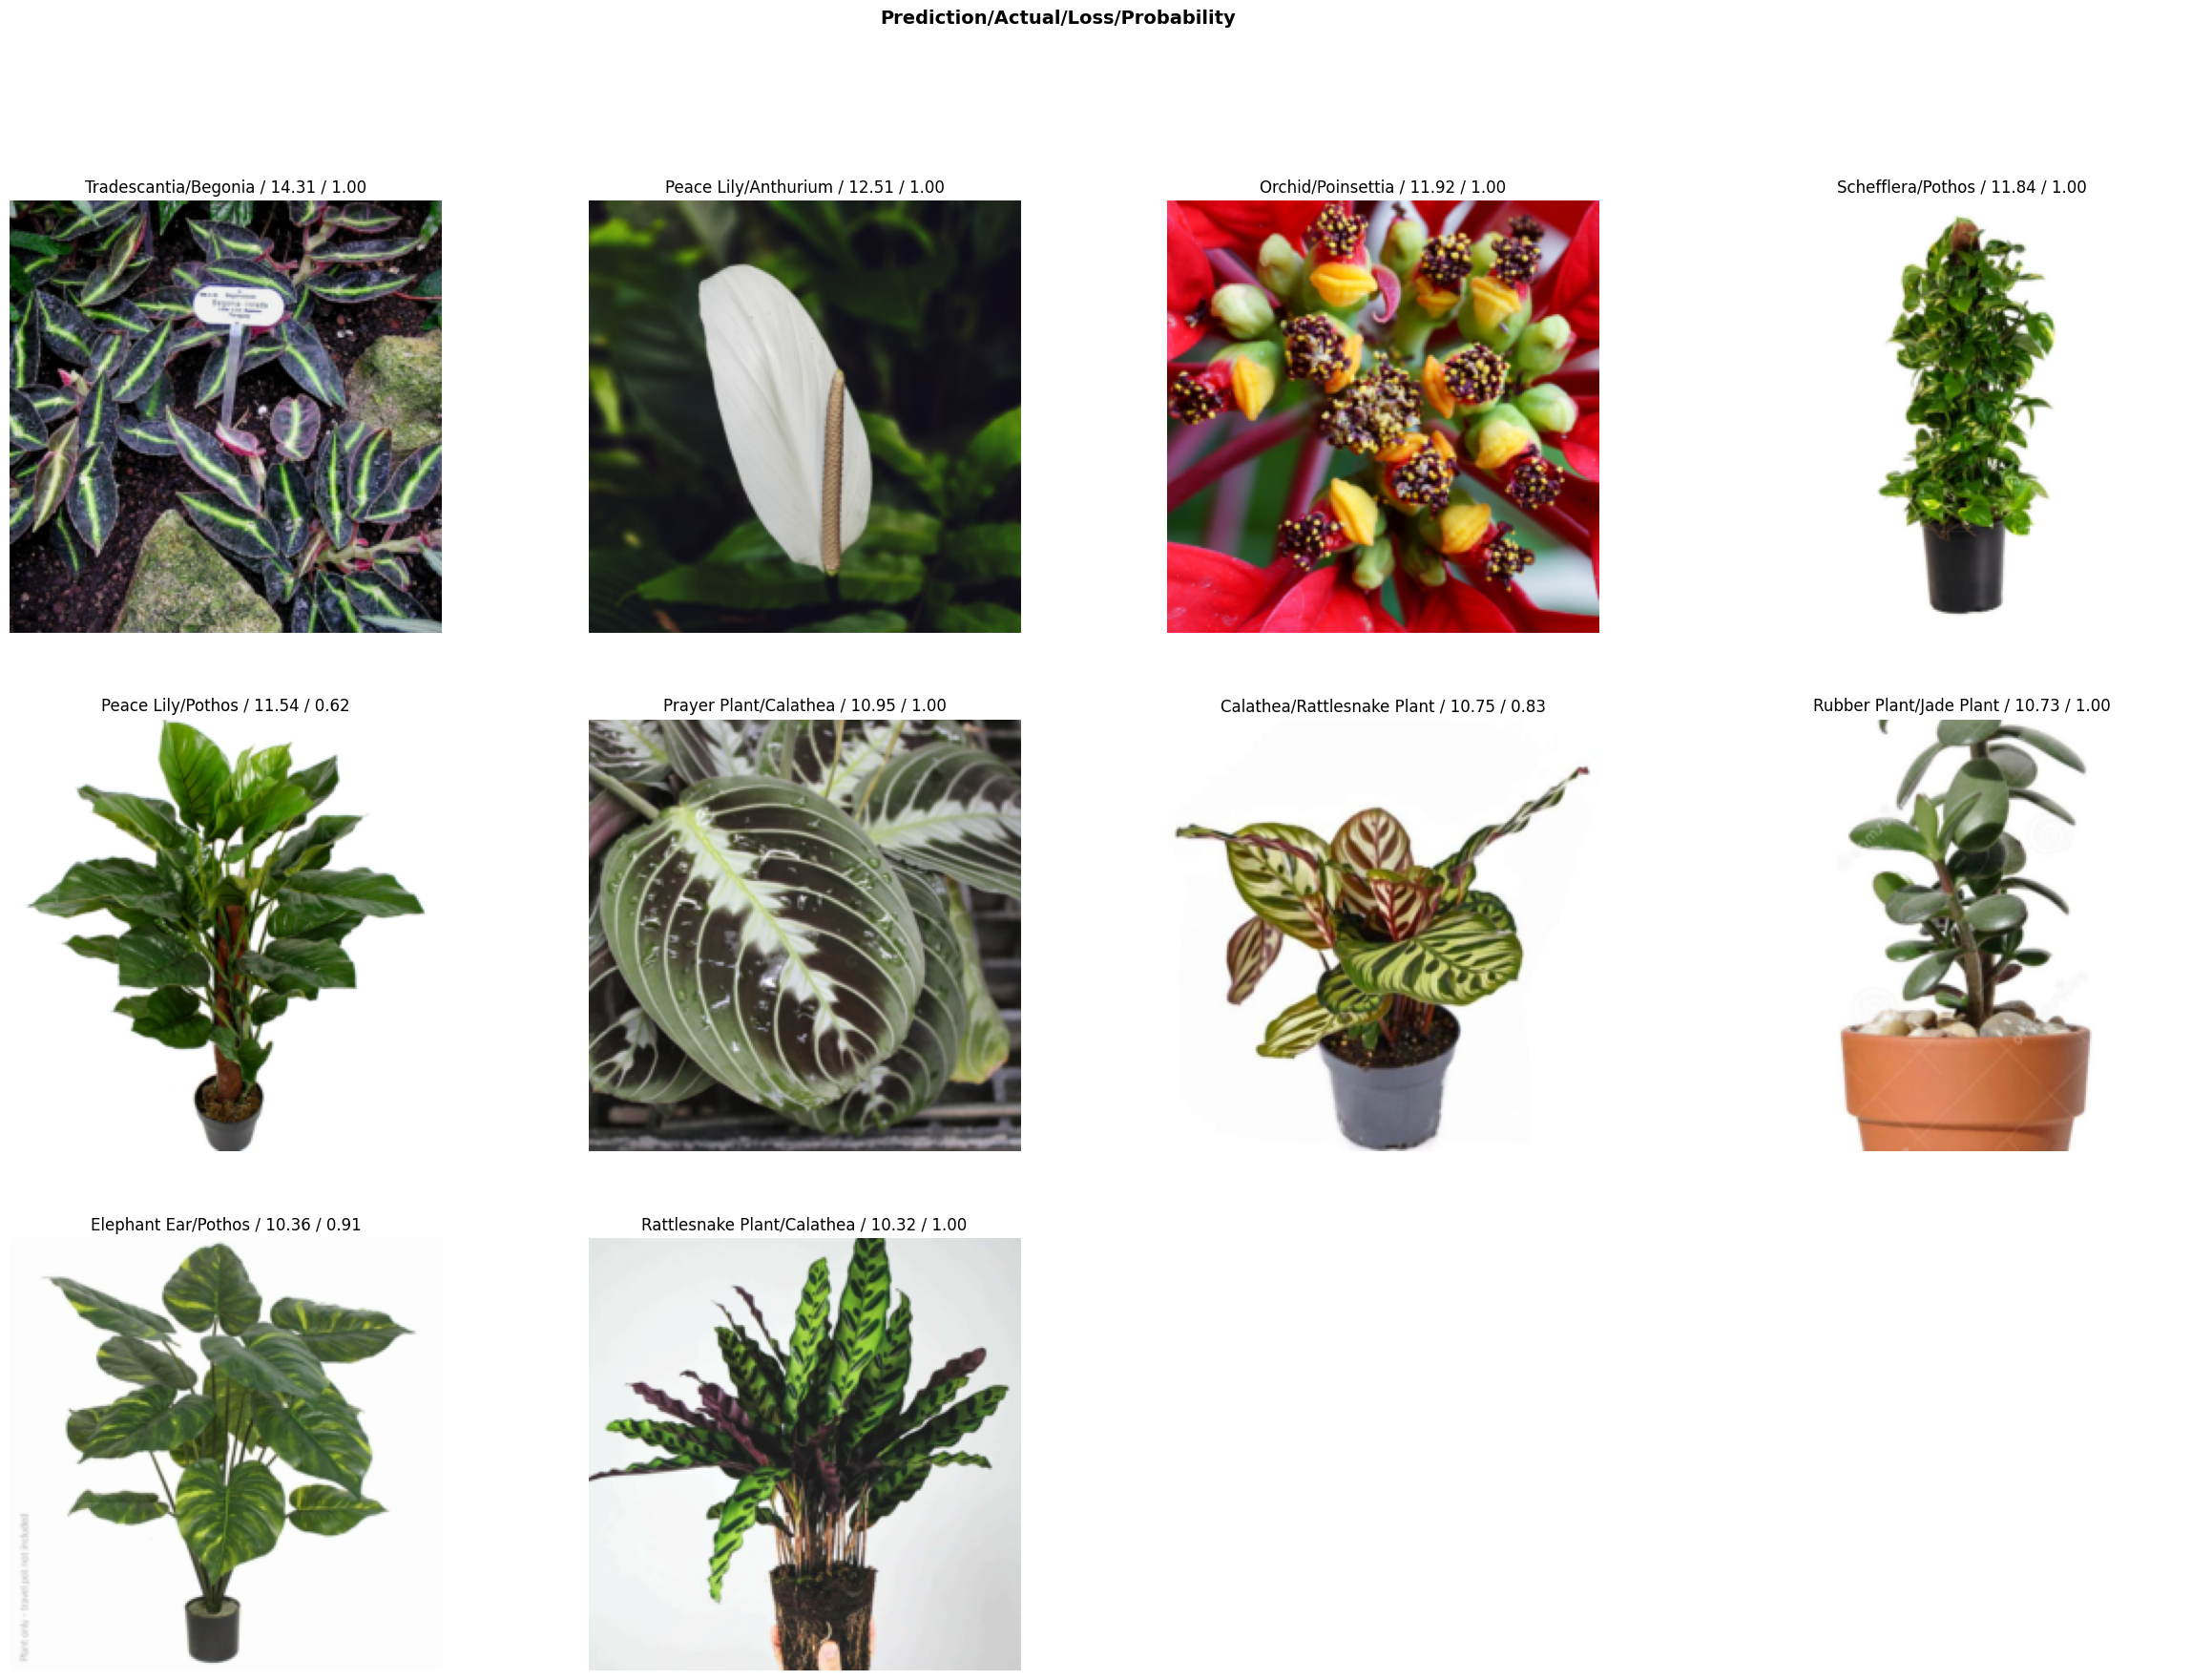

In [12]:
interp.plot_top_losses(10, figsize=(30,20))

In [15]:
learn.predict('images.jpg')

('Aloe Vera',
 TensorBase(1),
 TensorBase([9.3237e-11, 1.0000e+00, 2.0158e-12, 2.8785e-11, 4.2854e-09,
             6.0806e-11, 7.7659e-13, 8.0437e-11, 1.2584e-11, 3.2718e-09,
             8.0761e-13, 2.4218e-12, 4.5840e-11, 1.6191e-10, 2.5232e-13,
             6.6025e-12, 1.2016e-12, 3.6804e-08, 3.4106e-12, 3.3414e-12,
             4.1695e-13, 1.4063e-12, 3.7482e-12, 1.1668e-13, 1.3783e-11,
             1.4705e-13, 2.7293e-11, 2.2845e-15, 1.0112e-12, 9.0940e-14,
             1.1815e-07, 1.1267e-11, 1.0909e-11, 3.5721e-12]))